#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package to navigate through files and folders
import os

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart

# import of modules important for locking
from opentnsim.lock import lock as lock_module
from opentnsim.vessel_traffic_service import vessel_traffic_service as vessel_traffic_service_module

# energy module packages added from 0103 notebook
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)
from opentnsim.graph import mixins as graph_module

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# package(s) needed for inspecting the output
import pandas as pd
import geopandas as gpd
import numpy as np

# plot libraries
import folium
import pickle

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev47+gbe28de4fe.d20260122


#### 

In [3]:
path = os.getcwd()
# lock_information = pickle.load(open(os.path.join(path, "..", "data", "lock_information.pickle"),'rb'))
lock_information = pickle.load(open(os.path.join(path, "data", "lock_information.pickle"),'rb'))

In [4]:
sub_FG = lock_information['modified_graph']
lock_length = lock_information["lock_length"]
lock_depth = lock_information["lock_depth"]
node_A = lock_information["registration_node_A"]
node_B = lock_information["registration_node_B"]

In [5]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.mixins.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 1. Run simulation
##### 1.1 Set mission and simpy environment with VTS

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [7]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# This is not the best way to assign the lock_depth but it works 
# Add constant general depth
for u, v in sub_FG.edges():
    # FG.edges[u, v]['GeneralDepth'] = 6
    sub_FG.edges[u, v]['GeneralDepth'] = lock_depth
    
env.graph = sub_FG

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=sub_FG, crs_m = "EPSG:28992") #Amersfoort / RD New reference system

##### 3.2 Create lock object

In [8]:
waiting_time_before_lock = 840 #seconds

lock = lock_module.IsLockComplex(
    env = env,
    name = 'Lock',
    node_open = lock_information["lock_node_A"],
    node_A = lock_information["lock_node_A"],
    node_B = lock_information["lock_node_B"],
    edge_waiting_area_A = lock_information["edge_waiting_area_A"], 
    edge_waiting_area_B = lock_information["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = 500.,
    distance_lock_doors_B_to_waiting_area_B = 500.,
    distance_from_start_node_to_lock_doors_A = lock_information["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = lock_information["distance_from_end_node_to_lock_doors_B"],
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    lock_length = lock_information["lock_length"],
    lock_width = lock_information["lock_width"],
    lock_depth = lock_information["lock_depth"],
    mandatory_waiting_time_before_lock = waiting_time_before_lock,
    levelling_time = 550,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    sailing_in_speed_sea = 1.0,
    sailing_in_speed_canal = 1.0,
    registration_nodes = [lock_information["registration_node_A"], lock_information["registration_node_B"]],
)

In [9]:
# print(lock_information["lock_depth"])
# print(lock.lock_depth)

##### 3.3 Create vessels

In [10]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,
    "name": 'Vessel',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": False, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2025, 1, 1, 0, 0, 0),
    # "geometry": env.graph.nodes[route[0]]['geometry'],
    # "route": route,             # the route to sail
    "geometry": env.graph.nodes[node_A]['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_A, node_B),      # required by Routeable
}  #  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

# start the simulation
env.process(mission(env, vessel_1))
env.run()

C:\Users\929509\OpenTNSim\opentnsim\lock\lock.py:1857: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\929509\OpenTNSim\opentnsim\lock\lock.py:1857: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\929509\OpenTNSim\opentnsim\lock\lock.py:1857: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclud

In [12]:
trajectory_gdf = pickle.load(open(os.path.join(path, "data", "volkerak_track.pickle"),'rb'))

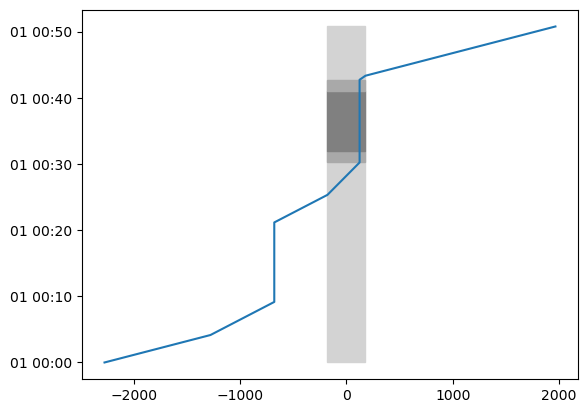

In [23]:
# Het lukt me even niet om de modelled en AIS tegelijk te plotten
# Het lijkt alsof er iets is veranderd in def lock.create_time_distance_plot

xlimmin = -2000
xlimmax = 2000
ylimmin = pd.Timestamp('2025-09-02 9:50:00')
ylimmax = pd.Timestamp('2025-09-02 11:00:00')

# We can plot the time-distance diagram
fig,ax = plt.subplots()

lock.create_time_distance_plot([vessel_1], xlimmin = xlimmin, xlimmax = xlimmax, ax = ax, label='modelled')

plt.show()

ax.plot(trajectory_gdf.distance_cumulative,trajectory_gdf.index, label='AIS')
ax.set_xlim([xlimmin,xlimmax])
ax.fill([-lock_length/2,-lock_length/2,lock_length/2,lock_length/2],
        [ylimmin,ylimmax,ylimmax,ylimmin],color='lightgrey',zorder=-1)
ax.set_ylim([ylimmin,ylimmax])
ax.legend()
plt.show()

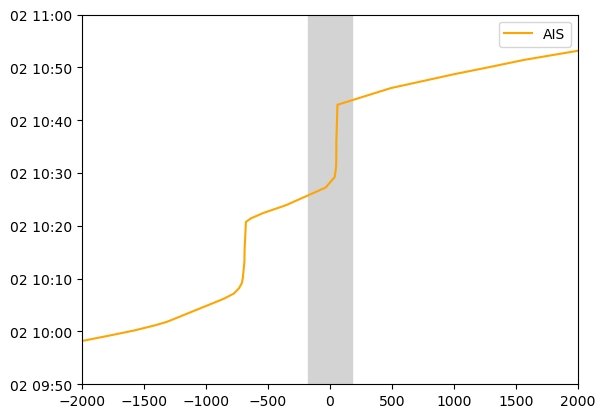

In [14]:
xlimmin = -2000
xlimmax = 2000
ylimmin = pd.Timestamp('2025-09-02 9:50:00')
ylimmax = pd.Timestamp('2025-09-02 11:00:00')

# We can plot the time-distance diagram
fig,ax = plt.subplots()

ax.plot(trajectory_gdf.distance_cumulative,trajectory_gdf.index, label='AIS', color='orange')
ax.set_xlim([xlimmin,xlimmax])
ax.fill([-lock_length/2,-lock_length/2,lock_length/2,lock_length/2],
        [ylimmin,ylimmax,ylimmax,ylimmin],color='lightgrey',zorder=-1)
ax.set_ylim([ylimmin,ylimmax])
ax.legend()

plt.show()

In [15]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8860743 to node 8862498 start,2025-01-01 00:00:00.000000,0,POINT (4.43615944214078 51.7022764335403)
1,Sailing from node 8860743 to node 8862498 stop,2025-01-01 00:01:59.152925,476.611698,POINT (4.43027504290525 51.7000442261129)
2,Sailing from node 8862498 to node B34113_A start,2025-01-01 00:01:59.152925,476.611698,POINT (4.43027504290525 51.7000442261129)
3,Sailing to waiting area start,2025-01-01 00:01:59.152925,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.43027504290525 51.7000442261129)
4,Sailing to waiting area stop,2025-01-01 00:04:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.42400509866192 51.69747197574123)
5,Sailing to waiting area start (with reduced sp...,2025-01-01 00:04:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.42400509866192 51.69747197574123)
6,Sailing to waiting area stop (with reduced speed),2025-01-01 00:09:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)
7,Waiting for lock operation start,2025-01-01 00:09:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)
8,Waiting for lock operation stop,2025-01-01 00:21:09.854830,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)
9,Sailing to first lock doors start,2025-01-01 00:21:09.854830,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)


In [16]:
lock.operation_planning.iloc[0]

node_from                                                                          8862498
node_to                                                                           B34113_A
direction                                                                                0
lock_chamber                                                                          Lock
vessels                                   [<__main__.Vessel object at 0x0000022FFD615BE0>]
capacity_L                                                                      247.101557
capacity_B                                                                       18.438854
time_potential_lock_door_opening_stop                                  2025-01-01 00:04:00
time_operation_start                                                   2025-01-01 00:11:30
time_entry_start                                                       2025-01-01 00:14:00
time_entry_stop                                              2025-01-01 00:18:53.619224534

In [17]:
lock.vessel_planning.iloc[0]

id                                        1d2247ef-7bc9-487e-86da-59d41bb40619
node_from                                                              8862498
node_to                                                               B34113_A
lock_chamber                                                               NaN
L                                                                          110
B                                                                         11.4
T                                                                          3.5
operation_index                                                              0
time_of_registration                                       2025-01-01 00:00:00
time_of_acceptance                                         2025-01-01 00:00:00
time_potential_lock_door_opening_stop                      2025-01-01 00:04:00
time_arrival_at_waiting_area                     2025-01-01 00:07:09.854830572
time_arrival_at_lineup_area                         

In [18]:
df_eventtable = logbook2eventtable([vessel_1])
# df_eventtable.head(5)
df_eventtable
# print("'{}' logbook data:".format(vessel_1.name))  

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8860743 to node 8862498,,POINT (4.43615944214078 51.7022764335403),POINT (4.43027504290525 51.7000442261129),2025-01-01 00:00:00,2025-01-01 00:01:59,476.611698,119.152925
1,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.42400509866192 51.69747197574123),2025-01-01 00:01:59,2025-01-01 00:04:09,538.500000,130.000000
2,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417425659251674 51.69396139614889),POINT (4.411964025200449 51.691016098663965),2025-01-01 00:21:10,2025-01-01 00:25:20,493.060000,250.000000
3,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:25:20,2025-01-01 00:30:13,298.240000,293.000000
4,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:30:13,2025-01-01 00:31:53,0.000000,100.000000
5,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:31:53,2025-01-01 00:41:03,0.000000,550.000000
6,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:41:03,2025-01-01 00:42:43,0.000000,100.000000
7,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.408656280617491 51.68924219105196),POINT (4.408054344012045 51.68891905583165),2025-01-01 00:42:43,2025-01-01 00:43:20,54.290000,37.000000
8,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node B34113_A to node B34113_B,,POINT (4.4077088440752465 51.688733575668216),POINT (4.407620736969263 51.688686277276325),2025-01-01 00:43:28,2025-01-01 00:43:30,8.050553,2.012639
9,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node B34113_B to node 8868426,,POINT (4.407620736969263 51.688686277276325),POINT (4.39253941691783 51.6812485487213),2025-01-01 00:43:30,2025-01-01 00:49:03,1331.492705,332.873176


In [19]:
generate_vessel_gantt_chart(df_eventtable)

In [20]:
# add energy attributes to the minimum event table
lock_depth = lock_information["lock_depth"]
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8860743 to node 8862498,,POINT (4.43615944214078 51.7022764335403),POINT (4.43027504290525 51.7000442261129),2025-01-01 00:00:00,2025-01-01 00:01:59,476.611698,119.152925,4.000000,6.2,None,0.0,571.183653,571.183653,1750.0,18.905056
1,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.42400509866192 51.69747197574123),2025-01-01 00:01:59,2025-01-01 00:04:09,538.500000,130.000000,4.142308,6.2,None,0.0,626.115731,626.115731,1750.0,22.609735
2,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417425659251674 51.69396139614889),POINT (4.411964025200449 51.691016098663965),2025-01-01 00:21:10,2025-01-01 00:25:20,493.060000,250.000000,1.972240,6.2,None,0.0,149.738241,149.738241,1750.0,10.398489
3,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:25:20,2025-01-01 00:30:13,298.240000,293.000000,1.017884,6.2,None,0.0,96.827831,96.827831,1750.0,7.880710
4,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:30:13,2025-01-01 00:31:53,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556
5,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:31:53,2025-01-01 00:41:03,0.000000,550.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,13.368056
6,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:41:03,2025-01-01 00:42:43,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556
7,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.408656280617491 51.68924219105196),POINT (4.408054344012045 51.68891905583165),2025-01-01 00:42:43,2025-01-01 00:43:20,54.290000,37.000000,1.467297,6.2,None,0.0,114.152758,114.152758,1750.0,1.173237
8,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node B34113_A to node B34113_B,,POINT (4.4077088440752465 51.688733575668216),POINT (4.407620736969263 51.688686277276325),2025-01-01 00:43:28,2025-01-01 00:43:30,8.050553,2.012639,3.999999,6.2,None,0.0,571.183166,571.183166,1750.0,0.319329
9,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node B34113_B to node 8868426,,POINT (4.407620736969263 51.688686277276325),POINT (4.39253941691783 51.6812485487213),2025-01-01 00:43:30,2025-01-01 00:49:03,1331.492705,332.873176,4.000000,6.2,None,0.0,571.183659,571.183659,1750.0,52.814366


In [21]:
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable, [vessel_1])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8860743 to node 8862498,,POINT (4.43615944214078 51.7022764335403),POINT (4.43027504290525 51.7000442261129),2025-01-01 00:00:00,2025-01-01 00:01:59,476.611698,119.152925,4.000000,6.2,None,0.0,571.183653,571.183653,1750.0,18.905056,1299.446651,2.726426,10.905705
1,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.42400509866192 51.69747197574123),2025-01-01 00:01:59,2025-01-01 00:04:09,538.500000,130.000000,4.142308,6.2,None,0.0,626.115731,626.115731,1750.0,22.609735,1554.089206,2.885960,11.954532
2,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417425659251674 51.69396139614889),POINT (4.411964025200449 51.691016098663965),2025-01-01 00:21:10,2025-01-01 00:25:20,493.060000,250.000000,1.972240,6.2,None,0.0,149.738241,149.738241,1750.0,10.398489,714.744317,1.449609,2.858977
3,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:25:20,2025-01-01 00:30:13,298.240000,293.000000,1.017884,6.2,None,0.0,96.827831,96.827831,1750.0,7.880710,541.683744,1.816268,1.848750
4,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:30:13,2025-01-01 00:31:53,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556,167.065213,0.000000,1.670652
5,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:31:53,2025-01-01 00:41:03,0.000000,550.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,13.368056,918.858673,0.000000,1.670652
6,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2025-01-01 00:41:03,2025-01-01 00:42:43,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556,167.065213,0.000000,1.670652
7,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.408656280617491 51.68924219105196),POINT (4.408054344012045 51.68891905583165),2025-01-01 00:42:43,2025-01-01 00:43:20,54.290000,37.000000,1.467297,6.2,None,0.0,114.152758,114.152758,1750.0,1.173237,80.642895,1.485410,2.179538
8,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node B34113_A to node B34113_B,,POINT (4.4077088440752465 51.688733575668216),POINT (4.407620736969263 51.688686277276325),2025-01-01 00:43:28,2025-01-01 00:43:30,8.050553,2.012639,3.999999,6.2,None,0.0,571.183166,571.183166,1750.0,0.319329,21.949229,2.726425,10.905696
9,1d2247ef-7bc9-487e-86da-59d41bb40619,Vessel 1,Sailing from node B34113_B to node 8868426,,POINT (4.407620736969263 51.688686277276325),POINT (4.39253941691783 51.6812485487213),2025-01-01 00:43:30,2025-01-01 00:49:03,1331.492705,332.873176,4.000000,6.2,None,0.0,571.183659,571.183659,1750.0,52.814366,3630.216704,2.726426,10.905705


In [22]:
# Event totals + unit conversion + speed 
df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
# df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['duration (min)']      = df_event['duration (s)'] / 60
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg_speed_m_s']     = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# --- Final summary table ---
summary = (
    df_event
    .join(df_H2[['H2_consumption (kg)']])
)

summary

,duration (s),distance (m),duration (min),distance (km),avg_speed_m_s,H2_consumption (kg)
object name,,,,,,
Vessel 1,2017.794936,3615.269741,33.629916,3.61527,1.791693,10.227296
